# ID3 Decision Tree 

In [1]:
import csv

def load_play_ball(path):
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        rows = []
        for row in reader:
            cleaned = {key.strip(): value.strip() for key, value in row.items()}
            rows.append(cleaned)
    return rows

data = load_play_ball("/kaggle/input/datasets/enigmatronix13/playball/dataset.csv")
target = "Play ball"
features = [key for key in data[0].keys() if key not in ("Day", target)]

In [2]:
import math
from collections import Counter

def entropy(rows, target_key):
    counts = Counter(row[target_key] for row in rows)
    total = len(rows)
    return -sum((count / total) * math.log2(count / total) for count in counts.values())

def information_gain(rows, feature, target_key):
    total_entropy = entropy(rows, target_key)
    total = len(rows)
    partitions = {}
    for row in rows:
        partitions.setdefault(row[feature], []).append(row)
    remainder = sum((len(subset) / total) * entropy(subset, target_key) for subset in partitions.values())
    return total_entropy - remainder

def majority_class(rows, target_key):
    counts = Counter(row[target_key] for row in rows)
    return max(counts.items(), key=lambda item: item[1])[0]

def build_tree(rows, feature_list, target_key, max_depth=None, depth=0):
    labels = set(row[target_key] for row in rows)
    if len(labels) == 1:
        return {"label": next(iter(labels))}
    if not feature_list or (max_depth is not None and depth >= max_depth):
        return {"label": majority_class(rows, target_key)}
    best_feature = max(feature_list, key=lambda f: information_gain(rows, f, target_key))
    tree = {"feature": best_feature, "nodes": {}}
    values = sorted(set(row[best_feature] for row in rows))
    for value in values:
        subset = [row for row in rows if row[best_feature] == value]
        remaining = [f for f in feature_list if f != best_feature]
        tree["nodes"][value] = build_tree(subset, remaining, target_key, max_depth, depth + 1)
    return tree

def print_tree(tree, indent=""):
    if "label" in tree:
        print(indent + "=> " + tree["label"])
        return
    print(indent + tree["feature"])
    for value, subtree in tree["nodes"].items():
        print(indent + f"- {value}:")
        print_tree(subtree, indent + "  " )

tree = build_tree(data, features, target)
print_tree(tree)

Outlook
- Overcast:
  => Yes
- Rain:
  Wind
  - Strong:
    => No
  - Weak:
    => Yes
- Sunny:
  Humidity
  - High:
    => No
  - Normal:
    => Yes


In [3]:
def extract_rules(tree, prefix=None):
    if prefix is None:
        prefix = []
    if "label" in tree:
        condition = " and ".join(prefix) if prefix else "TRUE"
        return [(condition, tree["label"]) ]
    rules = []
    for value, subtree in tree["nodes"].items():
        next_prefix = prefix + [f"{tree['feature']}={value}"]
        rules.extend(extract_rules(subtree, next_prefix))
    return rules

rules = extract_rules(tree)
for condition, label in rules:
    print(f"IF {condition} THEN Play ball={label}")

IF Outlook=Overcast THEN Play ball=Yes
IF Outlook=Rain and Wind=Strong THEN Play ball=No
IF Outlook=Rain and Wind=Weak THEN Play ball=Yes
IF Outlook=Sunny and Humidity=High THEN Play ball=No
IF Outlook=Sunny and Humidity=Normal THEN Play ball=Yes


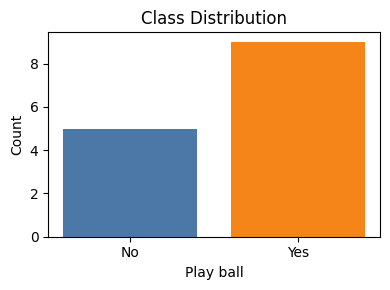

In [4]:
import matplotlib.pyplot as plt

counts = Counter(row[target] for row in data)
labels = list(counts.keys())
values = [counts[label] for label in labels]

plt.figure(figsize=(4, 3))
plt.bar(labels, values, color=["#4C78A8", "#F58518"])
plt.title("Class Distribution")
plt.xlabel("Play ball")
plt.ylabel("Count")
plt.tight_layout()
plt.show()